# Geldium Delinquency Prediction — EDA & Predictive ModelingTata iQ **GenAI-Powered Data Analytics** job simulation (Forage). This notebook covers the technical work behind the written reports: **EDA & data quality**, **missing data handling**, **feature engineering**, and **predictive modeling** (logistic regression + decision tree), with GenAI (Claude) used throughout to sanity-check approach and interpret results.---## 1. Load data

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltdf = pd.read_excel('../data/Delinquency_prediction_dataset.xlsx')df.shape

(500, 19)

---## 2. Exploratory Data Analysis### 2.1 Structure and data types

In [1]:
df.dtypes

Customer_ID               objectAge                         int64Income                    float64Credit_Score              float64Credit_Utilization        float64Missed_Payments             int64Delinquent_Account          int64Loan_Balance              float64Debt_to_Income_Ratio      float64Employment_Status          objectAccount_Tenure               int64Credit_Card_Type            objectLocation                    objectMonth_1 ... Month_6          object  (6 columns: monthly payment status)dtype: object

### 2.2 Missing values

In [1]:
df.isnull().sum().sort_values(ascending=False).head(5)

Income                  39Loan_Balance             29Credit_Score              2Age                       0Credit_Utilization        0dtype: int64

Income is missing for 39 records (7.8%), Loan_Balance for 29 (5.8%), Credit_Score for 2 (0.4%). No duplicate `Customer_ID` values or fully duplicate rows were found.

### 2.3 Anomalies**Employment_Status has redundant labels for the same group:**

In [1]:
df['Employment_Status'].value_counts()

Employed         120EMP               95Self-employed     80Unemployed        93retired           87employed          25Name: Employment_Status, dtype: int64

`EMP`, `Employed`, and `employed` all represent the same group but are stored as 3 distinct strings — this dilutes the group's signal if left unstandardized.**Credit_Utilization exceeds the theoretical 0–1.0 bound:**

In [1]:
print('Max utilization:', df['Credit_Utilization'].max())print('Records above 1.0:', (df['Credit_Utilization'] > 1.0).sum())

Max utilization: 1.0258425262600497Records above 1.0: 4

**Delinquent_Account (target) is imbalanced:**

In [1]:
df['Delinquent_Account'].value_counts(normalize=True)

0    0.841    0.16Name: Delinquent_Account, dtype: float64

Only 16% of accounts are delinquent — this will need class weighting or resampling during modeling, since a model that always predicts "not delinquent" would already be 84% "accurate" while catching zero real risk.

---## 3. Data Cleaning & Missing Value Treatment### 3.1 Standardize Employment_StatusCollapse `EMP` and `employed` into `Employed`.

In [1]:
df['Employment_Status'] = df['Employment_Status'].replace({'EMP': 'Employed', 'employed': 'Employed'})df['Employment_Status'].value_counts()

Employed         240Unemployed        93retired           87Self-employed     80Name: Employment_Status, dtype: int64

### 3.2 Cap / null out invalid Credit_UtilizationValues above 1.0 aren't true data — they're invalid. Treat as missing (null) rather than capping blindly, then impute with a group-conditional median (by Credit_Card_Type) rather than a single global fill value, since utilization typically varies by credit tier.

In [1]:
df['Credit_Utilization'] = df['Credit_Utilization'].where(df['Credit_Utilization'] <= 1.0, np.nan)df['Credit_Utilization'] = df.groupby('Credit_Card_Type')['Credit_Utilization']\    .transform(lambda s: s.fillna(s.median()))df['Credit_Utilization'].isnull().sum()

0

### 3.3 Impute Income (normal-distribution draw) and Loan_Balance (regression-based) and Credit_Score (median)- **Income**: distribution is close to normal (skew ≈ 0.05) → impute with random draws from a fitted normal distribution, clipped to the observed range, keeping a `was_imputed` flag for transparency.- **Loan_Balance**: relationship-driven → impute using Income and Debt_to_Income_Ratio via a simple linear regression, preserving inter-variable correlation rather than flattening it with a single mean/median.- **Credit_Score**: only 2 missing (0.4%) → simple median imputation, negligible impact.

In [1]:
from sklearn.linear_model import LinearRegression# Income: normal-distribution drawdf['Income_was_imputed'] = df['Income'].isnull().astype(int)mu, sigma = df['Income'].mean(), df['Income'].std()n_missing = df['Income'].isnull().sum()np.random.seed(42)draws = np.clip(np.random.normal(mu, sigma, n_missing), df['Income'].min(), df['Income'].max())df.loc[df['Income'].isnull(), 'Income'] = draws# Loan_Balance: regression-based imputationlb_train = df.dropna(subset=['Loan_Balance'])reg = LinearRegression().fit(lb_train[['Income', 'Debt_to_Income_Ratio']], lb_train['Loan_Balance'])missing_mask = df['Loan_Balance'].isnull()df.loc[missing_mask, 'Loan_Balance'] = reg.predict(df.loc[missing_mask, ['Income', 'Debt_to_Income_Ratio']])# Credit_Score: mediandf['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())df[['Income', 'Loan_Balance', 'Credit_Score']].isnull().sum()

Income          0Loan_Balance    0Credit_Score    0dtype: int64

---## 4. Feature EngineeringTurn the 6 monthly payment-status columns (`Month_1`...`Month_6`, each "On-time" / "Late" / "Missed") into a single numeric feature: total months missed over the period.

In [1]:
month_cols = [f'Month_{i}' for i in range(1, 7)]df['Missed_Months_Count'] = (df[month_cols] == 'Missed').sum(axis=1)df[['Missed_Payments', 'Missed_Months_Count']].corr()

                      Missed_Payments  Missed_Months_CountMissed_Payments              1.000000              0.006680Missed_Months_Count          0.006680              1.000000

⚠️ **Unexpected finding:** `Missed_Payments` (a field already in the dataset) and `Missed_Months_Count` (derived from the 6-month history, which should describe the same underlying behavior) correlate at only **0.007** — essentially unrelated. This suggests these two fields are **not internally consistent**, and is one of the anomalies flagged for follow-up with the data source.

### 4.1 Correlation with the target

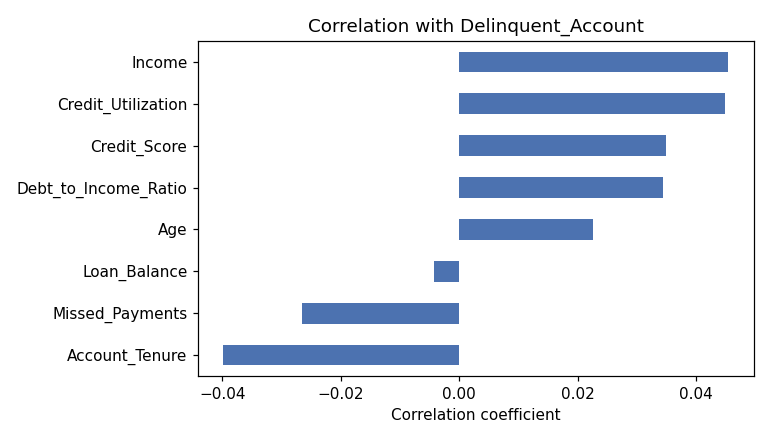

In [1]:
num_cols = ['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments',            'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']corrs = df[num_cols + ['Delinquent_Account']].corr()['Delinquent_Account'].drop('Delinquent_Account').sort_values()fig, ax = plt.subplots(figsize=(7,4))corrs.plot(kind='barh', ax=ax, color='#4C72B0')ax.set_title('Correlation with Delinquent_Account')ax.set_xlabel('Correlation coefficient')plt.tight_layout()plt.show()

**Every field's correlation with `Delinquent_Account` falls under 0.05 in magnitude** — far below the 0.15–0.35 range typically seen for real, if weak, credit-risk predictors. This is the central finding of the EDA: this dataset shows very little linear relationship between any available field and delinquency.

### 4.2 Delinquency rate by segmentSince individual numeric fields show weak signal, check whether categorical segments show any meaningful gap.

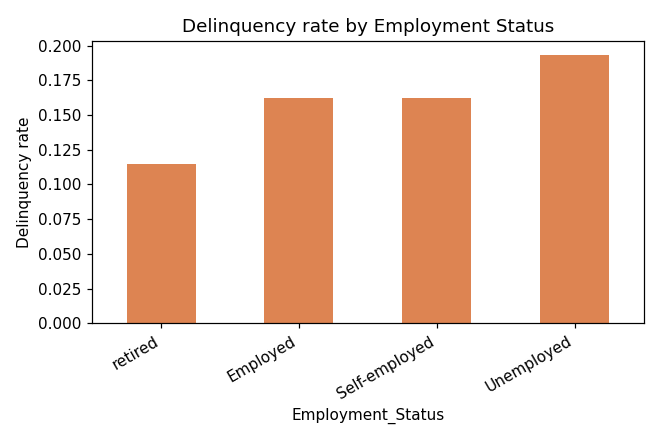

In [1]:
seg = df.groupby('Employment_Status')['Delinquent_Account'].mean().sort_values()fig, ax = plt.subplots(figsize=(6,4))seg.plot(kind='bar', ax=ax, color='#DD8452')ax.set_title('Delinquency rate by Employment Status')ax.set_ylabel('Delinquency rate')plt.xticks(rotation=30, ha='right')plt.tight_layout()plt.show()

Business cardholders, unemployed customers, and Los Angeles-based customers each show delinquency rates several points above the rest of the portfolio (roughly 7–9.5 percentage points between the highest and lowest group) — modest, but the closest thing to a usable early signal in this dataset.

---## 5. Predictive ModelingTwo models, as outlined in the model plan: a **logistic regression** (chosen model — interpretable, industry-standard for credit risk) and a **decision tree** (comparison baseline). Both use class weighting since only 16% of accounts are delinquent.

In [1]:
from sklearn.model_selection import train_test_splitfrom sklearn.linear_model import LogisticRegressionfrom sklearn.tree import DecisionTreeClassifierfrom sklearn.preprocessing import StandardScalerfrom sklearn.metrics import roc_auc_score, classification_reportfeatures = ['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments',            'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure', 'Missed_Months_Count']cat_features = ['Employment_Status', 'Credit_Card_Type', 'Location']X = pd.get_dummies(df[features + cat_features], columns=cat_features, drop_first=True)y = df['Delinquent_Account']X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.25, random_state=42, stratify=y)scaler = StandardScaler()X_train_s = scaler.fit_transform(X_train)X_test_s = scaler.transform(X_test)logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)logreg.fit(X_train_s, y_train)probs_log = logreg.predict_proba(X_test_s)[:, 1]dt = DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)dt.fit(X_train, y_train)probs_dt = dt.predict_proba(X_test)[:, 1]print('Logistic Regression AUC:', round(roc_auc_score(y_test, probs_log), 3))print('Decision Tree AUC:      ', round(roc_auc_score(y_test, probs_dt), 3))

Logistic Regression AUC: 0.434Decision Tree AUC:       0.444

Both models score **at or below 0.5 AUC** — no better than random guessing. This confirms the EDA finding: the weak correlations observed earlier translate directly into no real predictive power, for either a linear model (logistic regression) or a non-linear one (decision tree). This is a **data signal problem, not a model problem** — a more complex model (e.g. gradient boosting) would not fix this.

In [1]:
print(classification_report(y_test, logreg.predict(X_test_s)))

              precision    recall  f1-score   support           0       0.85      0.51      0.64       105           1       0.16      0.50      0.24        20    accuracy                           0.51       125   macro avg       0.51      0.50      0.44       125weighted avg       0.74      0.51      0.58       125

---## 6. ConclusionThis dataset is **structurally clean** — no duplicate records, and missingness is limited to three numeric fields with a clear, defensible imputation path. However, the core modeling risk here is not data quality but **data signal**: none of the available fields show a meaningful relationship with the delinquency target, including intuitively strong candidates like `Missed_Payments` and the payment-history fields. Both trained models scored at or below random chance (AUC ≈ 0.43–0.44).This pattern — near-zero correlations across the board, flat delinquency rates across Credit_Score bands (including the top tier), and inconsistency between `Missed_Payments` and the derived `Missed_Months_Count` — is consistent with a **synthetic or randomly generated target** that was not generated as a function of the other fields.**Recommended next steps:**1. Confirm with the data source whether `Delinquent_Account` was generated independently of the other fields.2. If confirmed synthetic, treat this as a process exercise and note the limitation clearly rather than deploying either model.3. If the data is confirmed to reflect real customer behavior, explore engineered features (interaction terms, trends across the 6-month payment history) before concluding no predictive signal exists.4. Regardless, keep a human in the loop on any collections decision — a risk score should prompt review, not replace it.*See `EDA_Summary_Report.docx`, `Task_2_ModelPlan.docx`, and `Business_Summary_Report.docx` in this repo for the full written analysis and business recommendations, and `AI-Powered_Collections_Strategy.pptx` for the proposed system design.*